# 05 — Association Rules: Pola Pembelian (FP-Growth)

Notebook ini menemukan produk yang sering dibeli bersamaan menggunakan algoritma FP-Growth dari Spark MLlib.

## 1. Setup

In [7]:
import os
from dotenv import load_dotenv
load_dotenv()

import sys
sys.path.insert(0, "/home/jovyan/work")

from analysis.spark_session import create_spark_session
spark = create_spark_session("05 - Association Rules")

## 2. Baca Data

In [8]:
BUCKET = "datalake"

df_orders   = spark.read.csv(f"s3a://{BUCKET}/raw/rdbms/orders/*/orders_from_db.csv",     header=True, inferSchema=True)
df_products = spark.read.csv(f"s3a://{BUCKET}/raw/xlsx/products/*/products_from_xlsx.csv", header=True, inferSchema=True)

print(f"Orders   : {df_orders.count()} baris")
print(f"Products : {df_products.count()} baris")

Orders   : 63 baris
Products : 15 baris


## 3. Bangun Format Transaksi

In [9]:
from analysis.preprocessing import build_transaction_items

df_transactions = build_transaction_items(df_orders, df_products)

print("Format transaksi per pelanggan:")
df_transactions.show(5, truncate=False)

Format transaksi per pelanggan:
+-----------+---------------------------------------------------------+
|customer_id|items                                                    |
+-----------+---------------------------------------------------------+
|28         |[Kopi Arabika 200g, Sepatu Lari Nike]                    |
|26         |[Sepatu Lari Nike, Teh Hijau Premium]                    |
|27         |[Bola Futsal Mikasa, Sepatu Lari Nike, Kopi Arabika 200g]|
|12         |[Kopi Arabika 200g, Mie Instan Goreng]                   |
|22         |[Kaos Polos Cotton, Celana Jeans Slim]                   |
+-----------+---------------------------------------------------------+
only showing top 5 rows



## 4. Jalankan FP-Growth

In [10]:
from analysis.mining.association import run_fpgrowth

# min_support=0.1 → itemset harus muncul di ≥ 10% transaksi (~3 pelanggan dari 30)
# min_confidence=0.5 → P(B|A) minimal 50%
df_freq_items, df_rules = run_fpgrowth(
    df_transactions,
    items_col="items",
    min_support=0.1,
    min_confidence=0.5,
)

print(f"Frequent itemsets ditemukan : {df_freq_items.count()}")
print(f"Association rules ditemukan : {df_rules.count()}")

Frequent itemsets ditemukan : 18
Association rules ditemukan : 7


## 5. Frequent Itemsets

In [11]:
print("=== Top Frequent Itemsets ===")
df_freq_items.orderBy("freq", ascending=False).show(15, truncate=False)

=== Top Frequent Itemsets ===
+---------------------------------------------------+----+
|items                                              |freq|
+---------------------------------------------------+----+
|[Kopi Arabika 200g]                                |9   |
|[Kaos Polos Cotton]                                |7   |
|[Teh Hijau Premium]                                |5   |
|[Sepatu Lari Nike]                                 |5   |
|[Headphone Sony WH-1000XM5]                        |4   |
|[Panci Presto 5L]                                  |4   |
|[Smartphone Samsung A54]                           |4   |
|[Laptop ASUS VivoBook]                             |4   |
|[Jaket Hoodie Fleece]                              |4   |
|[Headphone Sony WH-1000XM5, Smartphone Samsung A54]|3   |
|[Mie Instan Goreng]                                |3   |
|[Keyboard Mechanical Rexus]                        |3   |
|[Keyboard Mechanical Rexus, Laptop ASUS VivoBook]  |3   |
|[Celana Jeans Slim]      

## 6. Association Rules

In [14]:
print("=== Association Rules (diurutkan berdasarkan lift) ===")
df_rules.select("antecedent", "consequent", "confidence", "lift").orderBy("lift", ascending=False).show(20, truncate=False)

=== Association Rules (diurutkan berdasarkan lift) ===
+---------------------------+---------------------------+----------+-----+
|antecedent                 |consequent                 |confidence|lift |
+---------------------------+---------------------------+----------+-----+
|[Laptop ASUS VivoBook]     |[Keyboard Mechanical Rexus]|0.75      |7.5  |
|[Laptop ASUS VivoBook]     |[Mouse Wireless Logitech]  |0.75      |7.5  |
|[Keyboard Mechanical Rexus]|[Laptop ASUS VivoBook]     |1.0       |7.5  |
|[Mouse Wireless Logitech]  |[Laptop ASUS VivoBook]     |1.0       |7.5  |
|[Headphone Sony WH-1000XM5]|[Smartphone Samsung A54]   |0.75      |5.625|
|[Smartphone Samsung A54]   |[Headphone Sony WH-1000XM5]|0.75      |5.625|
|[Sepatu Lari Nike]         |[Kopi Arabika 200g]        |0.6       |2.0  |
+---------------------------+---------------------------+----------+-----+



## 7. Visualisasi Top Rules

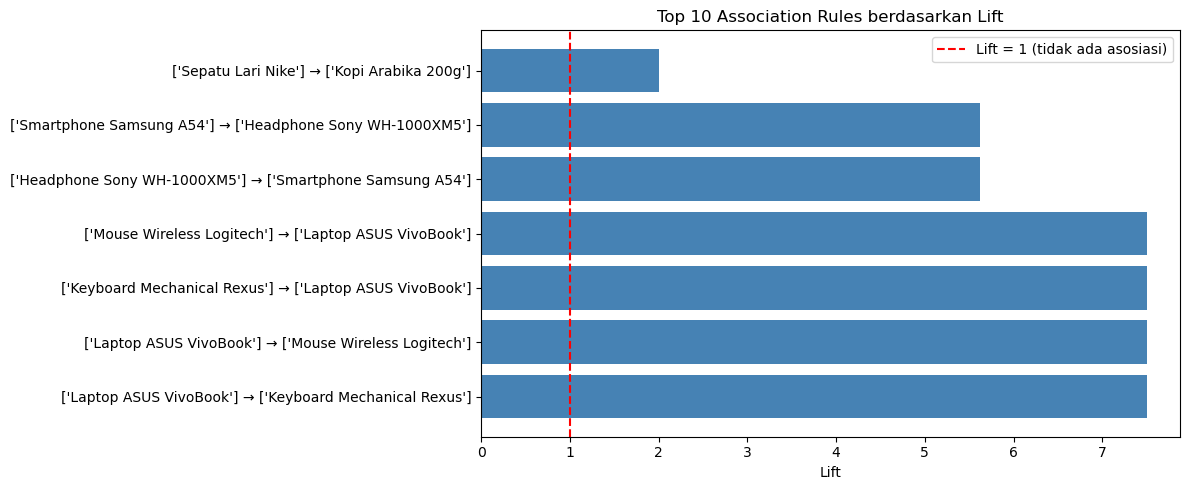

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

pdf_rules = df_rules.toPandas()
pdf_rules["rule"] = pdf_rules["antecedent"].apply(lambda x: str(x)) + " → " + pdf_rules["consequent"].apply(lambda x: str(x))
pdf_rules_top = pdf_rules.sort_values("lift", ascending=False).head(10)

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(pdf_rules_top["rule"], pdf_rules_top["lift"], color="steelblue")
ax.set_xlabel("Lift")
ax.set_title("Top 10 Association Rules berdasarkan Lift")
ax.axvline(x=1, color="red", linestyle="--", label="Lift = 1 (tidak ada asosiasi)")
ax.legend()
plt.tight_layout()
plt.show()

## 8. Simpan Rules ke MinIO

In [16]:
from pyspark.sql import functions as F

# Konversi kolom Array ke String agar kompatibel dengan format CSV
df_rules_csv = df_rules.withColumn(
    "antecedent", F.concat_ws(", ", F.col("antecedent"))
).withColumn(
    "consequent", F.concat_ws(", ", F.col("consequent"))
)

df_rules_csv.write.mode("overwrite").option("header", True) \
    .csv(f"s3a://{BUCKET}/processed/association_rules/")
print("Association rules disimpan ke processed zone.")

Association rules disimpan ke processed zone.
